# Sales Conversion Estimates Using Monte Carlo

## Project Overview
This notebook simulates lead conversions using Monte Carlo techniques. The goal is to estimate the revenue generated from merchant calls based on various conversion rates and lead counts.

**Business context.** Ahead of an outreach campaign, we needed to answer: if the team calls a given set of merchant leads, how much monthly payment volume would the converted merchants realistically yield? Point estimates hid too much uncertainty, so instead we simulate thousands of campaign outcomes to get a distribution — mean, spread, and worst/best case — for each conversion-rate scenario. The output was used to size campaigns and set expectations with stakeholders.

### Monte Carlo Simulation
Monte Carlo simulation helps model uncertain outcomes by running numerous trials with random inputs. This method provides probabilistic estimates, making it suitable for estimating lead conversion rates.

> **Data note:** the original analysis used per-cluster merchant opportunity amounts from the warehouse. This repo ships a synthetic, statistically similar sample (`data/opportunity_per_cluster_sample.csv`, generated by `data/generate_sample_data.py`) so the notebook runs end-to-end.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

np.random.seed(42)  # reproducible showcase runs

In [2]:
pd.options.display.float_format = '{:.2f}'.format

In [3]:
df = pd.read_csv('data/opportunity_per_cluster_sample.csv')  # synthetic sample - see data/generate_sample_data.py

In [4]:
def run_simulation(data, conversion_rate, n_simulations=10000):
    """
    Simulates lead conversions.
    
    Parameters:
    - data: DataFrame containing transaction amounts.
    - conversion_rate: Probability of conversion.
    - n_simulations: Number of simulation runs.
    
    Returns:
    - results: List of total converted amounts from each run.
    """
    results = []
    for _ in range(n_simulations):
        sampled_data = data.sample(frac=1, replace=True)
        sampled_data['converted'] = np.random.choice([0, 1], size=len(sampled_data), p=[1 - conversion_rate, conversion_rate])
        sampled_data['converted_amount'] = sampled_data['amount'] * sampled_data['converted']
        results.append(sampled_data['converted_amount'].sum())
    return results

In [5]:
def report_results(results):
    """
    Reports key statistics from simulation results.
    
    Parameters:
    - results: List of simulation results.
    
    Prints:
    - Mean, standard deviation, minimum, and maximum of results.
    """
    mean_amount = np.mean(results)
    std_amount = np.std(results)
    min_amount = np.min(results)
    max_amount = np.max(results)

    print(f"Mean Estimated Amount: ${mean_amount:,.2f}")
    print(f"Standard Deviation of Amount: ${std_amount:,.2f}")
    print(f"Minimum Estimated Amount: ${min_amount:,.2f}")
    print(f"Maximum Estimated Amount: ${max_amount:,.2f}")

In [6]:
def visualize_results(results, conversion_rate):
    """
    Displays a histogram of the results.
    
    Parameters:
    - results: Simulation results.
    - conversion_rate: Conversion probability.
    """
    def millions_formatter(x, pos):
        return f'${x * 1e-6:.1f}m'

    plt.figure(figsize=(10, 6))
    plt.hist(results, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f'Converted Amount - {int(conversion_rate * 100)}% Conversion Rate')
    plt.xlabel('Estimated Monthly Amount')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().xaxis.set_major_formatter(FuncFormatter(millions_formatter))
    plt.show()

### Step 1: Simulation Based on Historical Conversion Rates

In this step, the simulation runs for all records using pre-defined empirical conversion rates of 3%, 6%, and 9%. This approach models overall expected revenue based on previously observed conversion probabilities. This method assumes the entire dataset is subject to the same conversion probability.


Simulation for Conversion Rate: 3.0%
Mean Estimated Amount: $3,004,925.92
Standard Deviation of Amount: $145,264.12
Minimum Estimated Amount: $2,554,038.64
Maximum Estimated Amount: $3,770,864.36


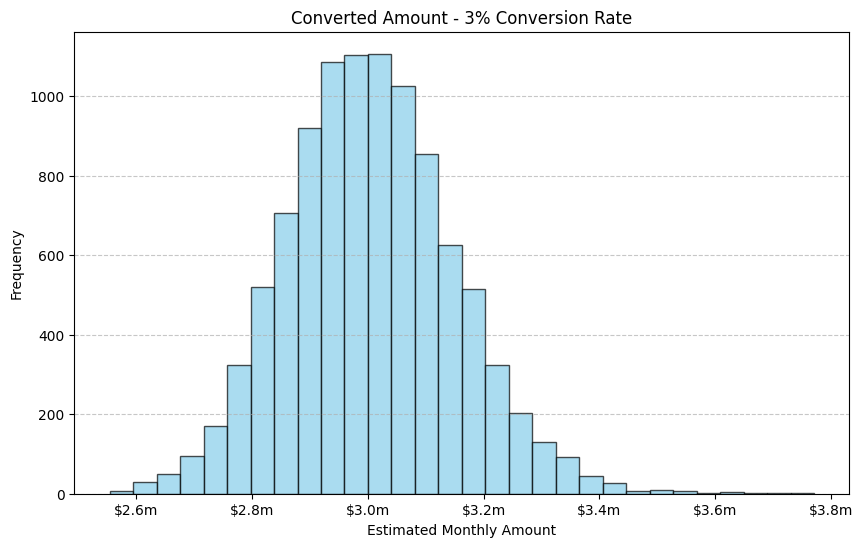


Simulation for Conversion Rate: 6.0%
Mean Estimated Amount: $6,009,009.36
Standard Deviation of Amount: $203,435.36
Minimum Estimated Amount: $5,280,808.72
Maximum Estimated Amount: $6,849,921.03


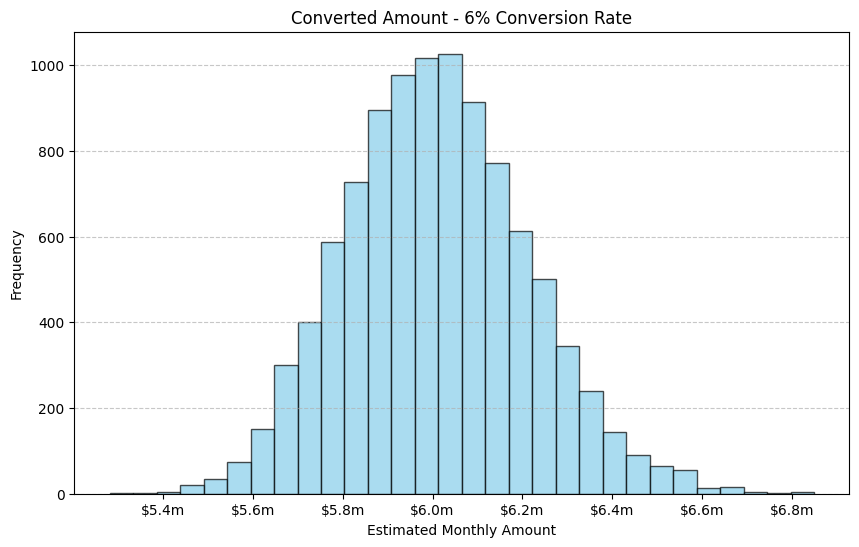


Simulation for Conversion Rate: 9.0%
Mean Estimated Amount: $9,016,173.79
Standard Deviation of Amount: $249,015.11
Minimum Estimated Amount: $8,139,603.41
Maximum Estimated Amount: $10,091,463.09


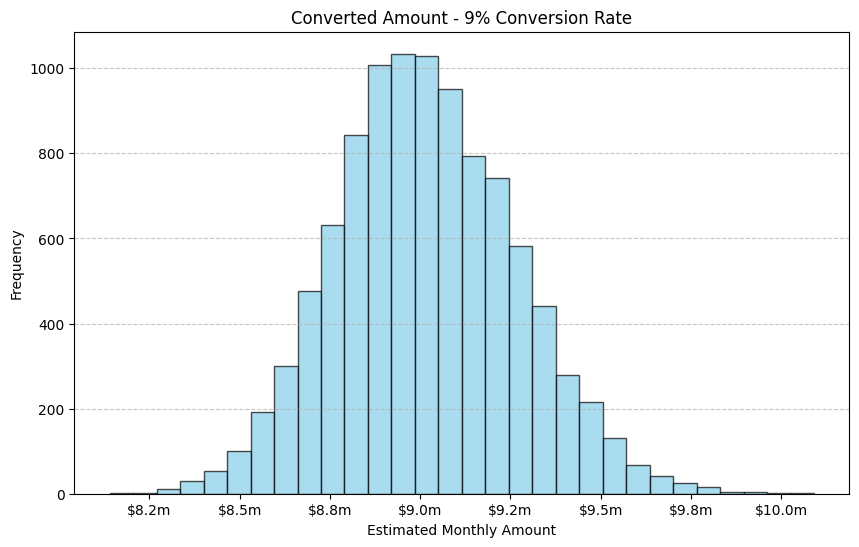

In [7]:
for rate in [0.03, 0.06, 0.09]:
    print(f"\nSimulation for Conversion Rate: {rate * 100}%")
    simulation_results = run_simulation(df, rate)
    report_results(simulation_results)
    visualize_results(simulation_results, rate)

### Step 2: Simulation Based on Record Count and Conversion Rate

In this step, the simulation targets specific subsets of the dataset, using different record counts and associated conversion rates. Each scenario reflects distinct marketing campaign assumptions or business strategies, considering varying customer volumes and conversion likelihoods.

In [8]:
lead_exercises = [
    {'record_count': 10000, 'conversion_rate': 0.20},
    {'record_count': 30000, 'conversion_rate': 0.15},
    {'record_count': 50000, 'conversion_rate': 0.10}
]

exercise_results = []

for exercise in lead_exercises:
    results = run_simulation(df.sample(n=exercise['record_count']), exercise['conversion_rate'])
    exercise_result = {
        'Record Count': exercise['record_count'],
        'Conversion Rate': exercise['conversion_rate'],
        'Mean Amount': np.mean(results),
        'Min Amount': np.min(results),
        'Max Amount': np.max(results),
        'Std Deviation Amount': np.std(results)
    }
    exercise_results.append(exercise_result)

results_df = pd.DataFrame(exercise_results)

In [9]:
results_df

,Record Count,Conversion Rate,Mean Amount,Min Amount,Max Amount,Std Deviation Amount
0,10000,0.20,3575080.81,3093706.87,4108489.68,146556.49
1,30000,0.15,8227916.58,7319251.59,9506153.90,245471.37
2,50000,0.10,9107452.00,8244759.71,10293579.16,251248.79


## Conclusions
1. **Predictive Insights:** Monte Carlo simulations effectively estimated lead conversion revenue for different scenarios.
2. **Data-Driven Decisions:** The results help allocate resources based on expected conversion rates.
3. **Scalability:** The simulation process can handle larger datasets and more complex models if needed.

By leveraging Monte Carlo simulations, we reduced uncertainty, enabling data-backed strategic planning.